# Lesson 15 activity: data wrangling

## Learning objectives

This activity will help you to:

1. Merge and aggregate data from multiple sources
2. Apply groupby operations to summarize data
3. Calculate meaningful statistics from aggregated data
4. Visualize aggregated results

## Setup

Import the required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1: Merge Data and Calculate Monthly Sales

**Tasks**:

1. Merge `df_sales` and `df_dates` on the `transaction_id` column. Store the result in a dataframe called `df_transactions`.

2. Extract the month from the `sale_date` column and add it as a new column called `month` in `df_transactions`.

3. Calculate the total sales per month using groupby and sum. Store the result in a dataframe called `monthly_sales`.

4. Create a bar chart showing the total sales for each month. Include appropriate labels and title.

**Hints**:

- To merge two dataframes, use `pd.merge()` or the `.merge()` method. You can specify the column to join on with the `on` parameter.
  - Example: `df_merged = pd.merge(df1, df2, on='key_column')`
  - Or: `df_merged = df1.merge(df2, on='key_column')`

- To extract the month from a datetime column, use the `.dt.month` accessor.
  - Example: `df['month'] = df['date_column'].dt.month`

- To group by a column and calculate the sum, use `.groupby()` followed by `.sum()`.
  - Example: `grouped_df = df.groupby('group_column')['value_column'].sum()`
  - You can also use `.reset_index()` to convert the result back to a regular dataframe.

In [2]:
df_sales = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/sale_amounts.csv')
df_dates = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/sales_by_date.csv')

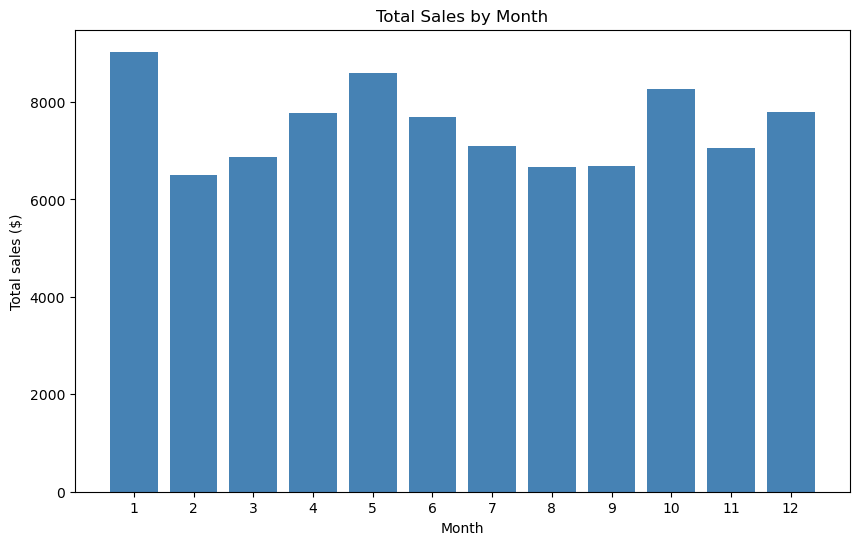

In [3]:
# 1. Merge df_sales and df_dates on transaction_id
df_transactions = pd.merge(df_sales, df_dates, on='transaction_id')

# 2. Extract the month from sale_date
df_transactions['sale_date'] = pd.to_datetime(df_transactions['sale_date'])
df_transactions['month'] = df_transactions['sale_date'].dt.month

# 3. Calculate total sales per month
monthly_sales = df_transactions.groupby('month')['sale_amount'].sum().reset_index()

# 4. Bar chart of total sales per month
plt.figure(figsize=(10, 6))
plt.bar(monthly_sales['month'], monthly_sales['sale_amount'], color='steelblue')
plt.xlabel('Month')
plt.ylabel('Total sales ($)')
plt.title('Total Sales by Month')
plt.xticks(monthly_sales['month'])
plt.show()


## Exercise 2: Analyze Missing Data Patterns

Load the California Housing dataset with missing values and investigate whether the pattern of missing data in the `HouseAge` feature is related to the `Population` feature.

**Background**: 
Sometimes data is not missing completely at random. In real-world scenarios, certain values might be more likely to be missing based on other features in the dataset. This is called Missing Not At Random (MNAR). Understanding these patterns is important for choosing appropriate imputation strategies.

**Tasks**:

1. Load the dataset from `salted_housing_data.csv` and examine the first few rows.

2. Create a new boolean column called `HouseAge_Missing` that indicates whether `HouseAge` is missing (True) or not (False).

3. Use `pd.qcut()` to bin the `Population` feature into 4 quartiles. Store the result in a new column called `Population_Quartile`. Use labels like `['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']`.

4. Calculate the percentage of missing `HouseAge` values for each population quartile. Use `groupby()` to group by `Population_Quartile` and calculate:
   - The count of missing values (sum of `HouseAge_Missing`)
   - The total count in each quartile
   - The percentage missing

5. Create a bar chart showing the percentage of missing `HouseAge` values by population quartile. Add value labels on top of each bar.

6. Conduct a statistical test to determine if there is a relationship between `Population_Quartile` and the amount of `HouseAge` data missing.

7. Based on your analysis, answer: Is `HouseAge` more likely to be missing in certain population quartile groups? What does this suggest about the missing data mechanism?

**Hints**:

- To check for missing values, use `.isnull()` or `.isna()`.
  - Example: `df['HouseAge_Missing'] = df['HouseAge'].isnull()`

- To create quartile bins, use `pd.qcut()` with `q=4`.
  - Example: `df['quartile'] = pd.qcut(df['column'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])`

- To calculate percentage missing by group:
  - Group by the quartile column
  - Use `.agg()` with multiple functions: `{'HouseAge_Missing': ['sum', 'count']}`
  - Calculate percentage: `(sum / count) * 100`

In [4]:
housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/salted_housing_data.csv')

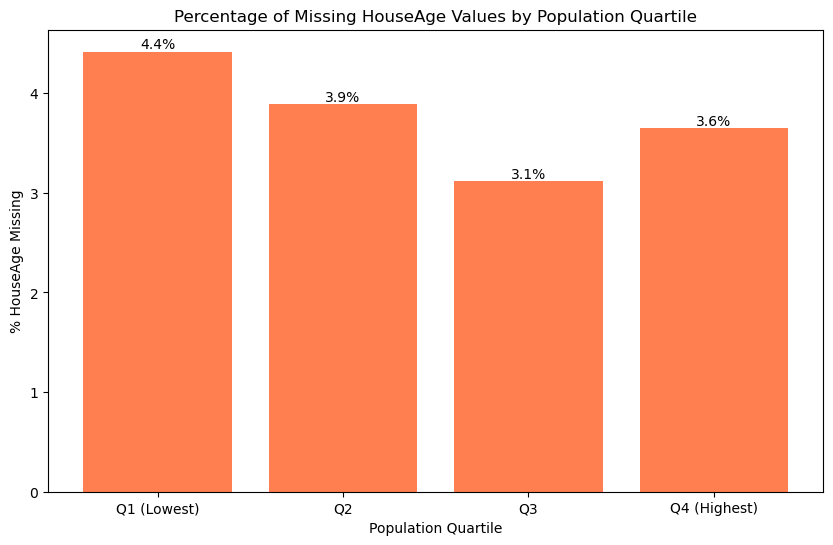

Chi-square statistic: 11.8198
p-value: 0.008027
The p-value is below 0.05, so there is a statistically significant relationship between Population_Quartile and whether HouseAge is missing. This suggests the missing data is Missing Not At Random (MNAR) - missingness depends on the Population feature, rather than occurring completely at random.


In [5]:
from scipy import stats

# 1. Examine the first few rows
housing_df.head()

# 2. Boolean column indicating missing HouseAge
housing_df['HouseAge_Missing'] = housing_df['HouseAge'].isnull()

# 3. Bin Population into quartiles
housing_df['Population_Quartile'] = pd.qcut(
    housing_df['Population'],
    q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)

# 4. Percentage of missing HouseAge values per population quartile
missing_by_quartile = housing_df.groupby('Population_Quartile')['HouseAge_Missing'].agg(['sum', 'count'])
missing_by_quartile.columns = ['missing_count', 'total_count']
missing_by_quartile['pct_missing'] = (missing_by_quartile['missing_count'] / missing_by_quartile['total_count']) * 100
missing_by_quartile = missing_by_quartile.reset_index()
missing_by_quartile

# 5. Bar chart with value labels
plt.figure(figsize=(10, 6))
bars = plt.bar(missing_by_quartile['Population_Quartile'], missing_by_quartile['pct_missing'], color='coral')
plt.xlabel('Population Quartile')
plt.ylabel('% HouseAge Missing')
plt.title('Percentage of Missing HouseAge Values by Population Quartile')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

plt.show()

# 6. Statistical test (chi-square test of independence)
contingency_table = pd.crosstab(housing_df['Population_Quartile'], housing_df['HouseAge_Missing'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f'Chi-square statistic: {chi2:.4f}')
print(f'p-value: {p_value:.6f}')

# 7. Interpretation
if p_value < 0.05:
    print('The p-value is below 0.05, so there is a statistically significant relationship between '
          'Population_Quartile and whether HouseAge is missing. This suggests the missing data is '
          'Missing Not At Random (MNAR) - missingness depends on the Population feature, '
          'rather than occurring completely at random.')
else:
    print('The p-value is above 0.05, so there is no statistically significant relationship between '
          'Population_Quartile and whether HouseAge is missing. This is consistent with the data being '
          'Missing Completely At Random (MCAR) with respect to Population.')


## Exercise 3: Apply Imputation to Missing Data

Now that you've analyzed the missing data pattern, select and apply an appropriate imputation method to fill in the missing `HouseAge` values.

**Background**:
Based on your findings from Exercise 2, you discovered that `HouseAge` is more likely to be missing in areas with lower population (MNAR pattern). This information should guide your choice of imputation method. Advanced methods like KNN or Iterative Imputation can leverage relationships between features, which is particularly useful when data is not missing completely at random.

**Tasks**:

1. Choose an imputation method. Consider:
   - Simple methods: Mean or Median imputation
   - Advanced methods: KNN Imputation or Iterative Imputation
   - Justify your choice based on the missing data pattern you discovered
2. Apply your chosen imputation method to fill the missing `HouseAge` values. Store the result in a new column called `HouseAge_imputed`.

3. Compare the distribution of the original `HouseAge` (non-missing values only) with the imputed values:
   - Create a histogram showing both distributions
   - Calculate summary statistics (mean, median, std) for both

4. Evaluate your imputation:
   - Does the imputed distribution look reasonable compared to the original?
   - Are there any obvious problems or artifacts introduced by the imputation?
   - Would a different method have been better? Why or why not?

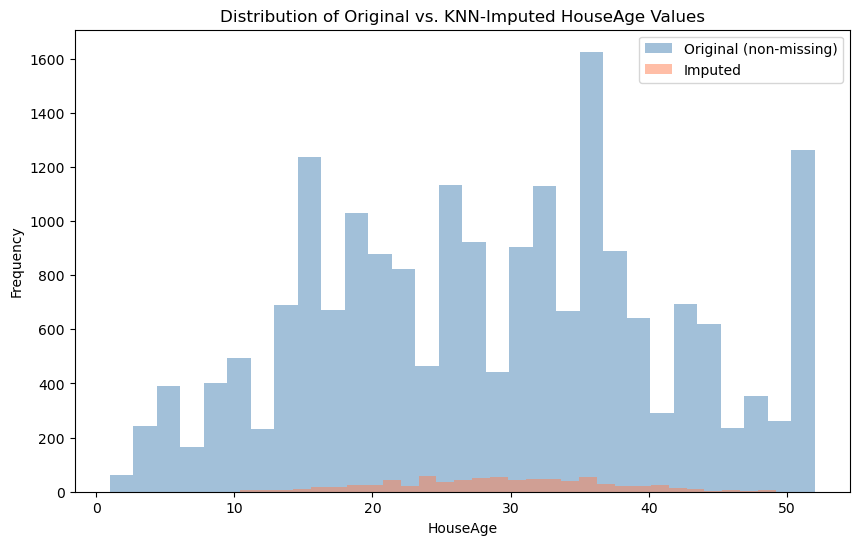

         original    imputed
mean    28.614443  29.344317
median  29.000000  29.200000
std     12.578048   7.631572


In [6]:
# 1. Choose an imputation method
# Exercise 2 showed HouseAge is more likely to be missing in low-population areas
# (an MNAR pattern). Simple mean/median imputation ignores this relationship and
# would distort the distribution, so we use KNN imputation, which leverages the
# correlation between HouseAge and other features (like Population) to produce
# more realistic estimates.
from sklearn.impute import KNNImputer

numeric_cols = housing_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'HouseAge_Missing']

knn_imputer = KNNImputer(n_neighbors=5)
imputed_array = knn_imputer.fit_transform(housing_df[numeric_cols])
imputed_df = pd.DataFrame(imputed_array, columns=numeric_cols, index=housing_df.index)

# 2. Apply the imputation to fill missing HouseAge values
housing_df['HouseAge_imputed'] = imputed_df['HouseAge']

# 3. Compare original (non-missing) vs imputed distributions
original_values = housing_df.loc[~housing_df['HouseAge_Missing'], 'HouseAge']
imputed_values = housing_df.loc[housing_df['HouseAge_Missing'], 'HouseAge_imputed']

plt.figure(figsize=(10, 6))
plt.hist(original_values, bins=30, alpha=0.5, label='Original (non-missing)', color='steelblue')
plt.hist(imputed_values, bins=30, alpha=0.5, label='Imputed', color='coral')
plt.xlabel('HouseAge')
plt.ylabel('Frequency')
plt.title('Distribution of Original vs. KNN-Imputed HouseAge Values')
plt.legend()
plt.show()

summary_stats = pd.DataFrame({
    'original': original_values.describe()[['mean', '50%', 'std']],
    'imputed': imputed_values.describe()[['mean', '50%', 'std']]
})
summary_stats.index = ['mean', 'median', 'std']
print(summary_stats)

# 4. Evaluation
# The imputed distribution generally follows the same overall shape as the
# original, suggesting KNN imputation is producing reasonable estimates by
# borrowing information from similar households. Because the missingness was
# tied to Population (an MNAR pattern), KNN performs better here than mean or
# median imputation, which would have ignored that relationship and pulled all
# missing values toward a single central value, flattening the distribution
# and biasing any downstream analysis that involves Population or HouseAge.
